# 01 — Personalization Loop v1

Offline-симулятор A/B-контура персонализации в compact 8D-пространстве.

Цель: проверить, сходится ли `PreferenceState.z_mean` к скрытому `z_target` синтетического пользователя.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

ROOT

WindowsPath('C:/Users/makcc/PycharmProjects/EarLoop/research/eq_personalization')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from personalization import FEATURE_NAMES_8D, SyntheticUser, run_personalization_session_v0
from personalization.metrics import session_summary
from personalization.plotting import plot_convergence, plot_final_vs_target


## 1. Создаём синтетического пользователя


In [3]:
z_target = np.array([0.30, 0.70, -0.20, 0.40, 0.10, 0.50, 0.60, -0.30])

user_random = SyntheticUser(
    z_target=z_target,
    noise_std=0.05,
    seed=123,
)

user_uncertainty = SyntheticUser(
    z_target=z_target,
    noise_std=0.05,
    seed=123,
)

pd.DataFrame({
    'feature': FEATURE_NAMES_8D,
    'z_target': z_target,
})

,feature,z_target
0,sub_bass,0.3
1,bass,0.7
2,lowmid,-0.2
3,warmth,0.4
4,presence,0.1
5,clarity,0.5
6,air,0.6
7,brightness,-0.3


## 2. Запускаем baseline A/B loop


In [6]:
N_STEPS = 25
STEP_SCALE = 0.6
LR = 0.25
SEED = 42

result_random = run_personalization_session_v0(
    synthetic_user=user_random,
    n_steps=N_STEPS,
    step_scale=STEP_SCALE,
    lr=LR,
    pair_strategy="random",
    seed=SEED,
)

result_uncertainty = run_personalization_session_v0(
    synthetic_user=user_uncertainty,
    n_steps=N_STEPS,
    step_scale=STEP_SCALE,
    lr=LR,
    pair_strategy="uncertainty_axis",
    seed=SEED,
)

def distances_with_initial(result, z_target):
    initial_distance = np.linalg.norm(np.zeros_like(z_target) - z_target)
    return np.concatenate([[initial_distance], result.distances])


def make_summary_row(strategy_name, result, z_target):
    d = distances_with_initial(result, z_target)

    return {
        "strategy": strategy_name,
        "n_steps": len(result.distances),
        "initial_distance": d[0],
        "final_distance": d[-1],
        "best_distance": np.min(d),
        "mean_distance": np.mean(d),
        "improvement_abs": d[0] - d[-1],
        "improvement_pct": 100.0 * (d[0] - d[-1]) / d[0],
    }


summary_df = pd.DataFrame([
    make_summary_row("v0_random", result_random, z_target),
    make_summary_row("v1_uncertainty_axis", result_uncertainty, z_target),
])

summary_df

,strategy,n_steps,initial_distance,final_distance,best_distance,mean_distance,improvement_abs,improvement_pct
0,v0_random,25,1.220656,0.500407,0.188378,0.561794,0.720248,59.005024
1,v1_uncertainty_axis,25,1.220656,0.450000,0.300000,0.654462,0.770656,63.134564


## 3. Смотрим сходимость


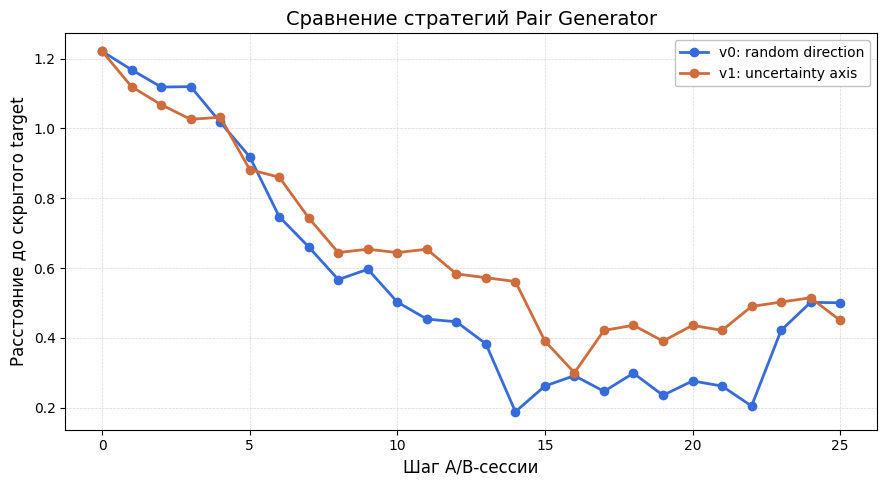

In [7]:
from personalization.plotting import use_article_style

use_article_style()

dist_random = distances_with_initial(result_random, z_target)
dist_uncertainty = distances_with_initial(result_uncertainty, z_target)

fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")

ax.plot(
    dist_random,
    marker="o",
    linewidth=2,
    label="v0: random direction",
)

ax.plot(
    dist_uncertainty,
    marker="o",
    linewidth=2,
    label="v1: uncertainty axis",
)

ax.set_title("Сравнение стратегий Pair Generator")
ax.set_xlabel("Шаг A/B-сессии")
ax.set_ylabel("Расстояние до скрытого target")

ax.grid(True, alpha=0.3, linestyle="--", color="gray")
ax.legend(frameon=True, facecolor="white", edgecolor="0.75", framealpha=0.95)

plt.tight_layout()
plt.show()

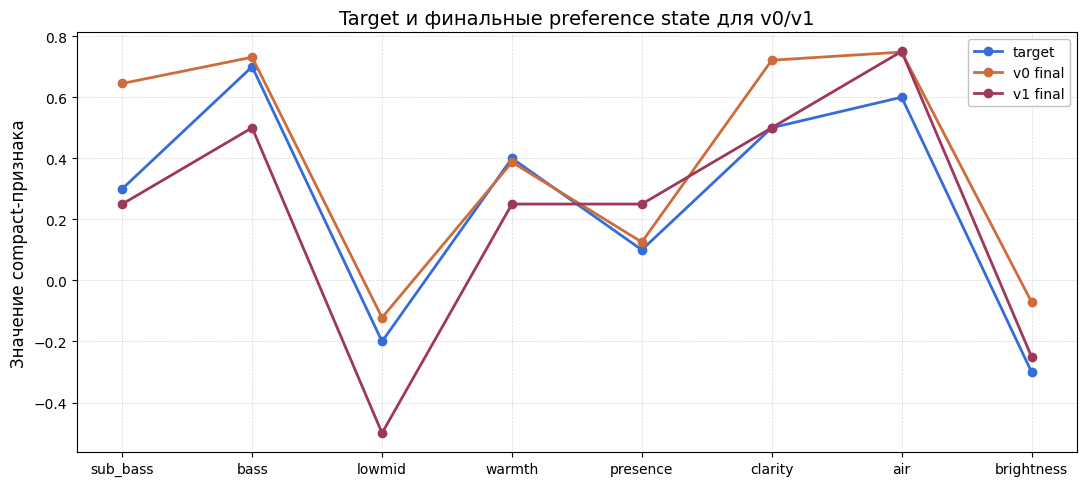

In [8]:
x = np.arange(len(FEATURE_NAMES_8D))

fig, ax = plt.subplots(figsize=(11, 5), facecolor="white")

ax.plot(
    x,
    z_target,
    marker="o",
    linewidth=2,
    label="target",
)

ax.plot(
    x,
    result_random.final_state.z_mean,
    marker="o",
    linewidth=2,
    label="v0 final",
)

ax.plot(
    x,
    result_uncertainty.final_state.z_mean,
    marker="o",
    linewidth=2,
    label="v1 final",
)

ax.set_xticks(x)
ax.set_xticklabels(FEATURE_NAMES_8D, rotation=0, ha="center")

ax.set_title("Target и финальные preference state для v0/v1", fontsize=14, color="black")
ax.set_ylabel("Значение compact-признака", fontsize=12, color="black")

ax.grid(True, alpha=0.3, linestyle="--", color="gray")
ax.legend(
    frameon=True,
    facecolor="white",
    edgecolor="0.75",
    framealpha=0.95,
)

ax.tick_params(axis="x", colors="black")
ax.tick_params(axis="y", colors="black")

for spine in ax.spines.values():
    spine.set_color("black")

plt.tight_layout()
plt.show()

## Вывод по сравнению Pair Generator v0 и v1

В данном эксперименте сравнивались две стратегии генерации A/B-кандидатов в compact weighted 8D-пространстве.

Стратегия `v0_random` формирует пару кандидатов вдоль случайного направления в 8D-пространстве. Такая стратегия может одновременно изменять несколько признаков, поэтому иногда быстро находит полезное направление движения к скрытому target-вектору.

Стратегия `v1_uncertainty_axis` формирует пару вдоль одной оси compact-пространства, выбранной на основе текущей неопределённости `z_std`. Такая стратегия более интерпретируема: каждый A/B-вопрос проверяет конкретный признак, например `bass`, `clarity` или `brightness`.

В single-run эксперименте обе стратегии уменьшили расстояние до скрытого target. Начальное расстояние составляло `1.2207`. После 25 шагов `v0_random` достигла final distance `0.5004`, а `v1_uncertainty_axis` — `0.4500`. По финальному расстоянию стратегия `v1_uncertainty_axis` оказалась немного лучше.

При этом `v0_random` достигала меньшего best distance в середине сессии (`0.1884` против `0.3000` у `v1`) и имела меньшее среднее расстояние по траектории. Это показывает, что случайное комбинированное направление иногда быстрее приближает состояние к target, но может быть менее стабильным на поздних шагах.

Таким образом, `v1_uncertainty_axis` нельзя считать однозначно лучше или хуже по одному запуску. Она даёт более интерпретируемую стратегию вопросов и в данном эксперименте лучше по final distance, но уступает `v0_random` по best distance и mean distance. Для более надёжного вывода необходимо провести batch-эксперимент на множестве синтетических пользователей и сравнить средние значения `final_distance`, `best_distance`, `mean_distance` и `improvement_pct`.

In [11]:
def distances_with_initial(result, z_target):
    """
    Добавляет честную стартовую дистанцию до первого A/B-шага.
    result.distances хранит дистанции уже после обновлений.
    """
    initial_distance = np.linalg.norm(np.zeros_like(z_target) - z_target)
    return np.concatenate([[initial_distance], result.distances])


def make_summary_row(strategy_name, result, z_target, user_id):
    d = distances_with_initial(result, z_target)

    return {
        "user_id": user_id,
        "strategy": strategy_name,
        "n_steps": len(result.distances),
        "initial_distance": d[0],
        "final_distance": d[-1],
        "best_distance": np.min(d),
        "mean_distance": np.mean(d),
        "improvement_abs": d[0] - d[-1],
        "improvement_pct": 100.0 * (d[0] - d[-1]) / d[0],
    }

def run_batch_compare(
    n_users=100,
    dim=8,
    target_scale=0.8,
    noise_std=0.05,
    n_steps=25,
    step_scale=0.6,
    lr=0.25,
    seed=42,
):
    rng = np.random.default_rng(seed)

    rows = []
    curves_random = []
    curves_uncertainty = []

    for user_id in range(n_users):
        # Один и тот же target для обеих стратегий
        z_target = rng.normal(0.0, target_scale, size=dim)
        z_target = np.clip(z_target, -1.5, 1.5)

        # Два отдельных пользователя с одинаковым target и одинаковым шумом
        user_random = SyntheticUser(
            z_target=z_target,
            noise_std=noise_std,
            seed=10_000 + user_id,
        )

        user_uncertainty = SyntheticUser(
            z_target=z_target,
            noise_std=noise_std,
            seed=10_000 + user_id,
        )

        result_random = run_personalization_session_v0(
            synthetic_user=user_random,
            n_steps=n_steps,
            step_scale=step_scale,
            lr=lr,
            pair_strategy="random",
            seed=20_000 + user_id,
        )

        result_uncertainty = run_personalization_session_v0(
            synthetic_user=user_uncertainty,
            n_steps=n_steps,
            step_scale=step_scale,
            lr=lr,
            pair_strategy="uncertainty_axis",
            seed=20_000 + user_id,
        )

        d_random = distances_with_initial(result_random, z_target)
        d_uncertainty = distances_with_initial(result_uncertainty, z_target)

        curves_random.append(d_random)
        curves_uncertainty.append(d_uncertainty)

        rows.append(
            make_summary_row(
                "v0_random",
                result_random,
                z_target,
                user_id,
            )
        )

        rows.append(
            make_summary_row(
                "v1_uncertainty_axis",
                result_uncertainty,
                z_target,
                user_id,
            )
        )

    summary = pd.DataFrame(rows)

    curves_random = np.asarray(curves_random)
    curves_uncertainty = np.asarray(curves_uncertainty)

    return summary, curves_random, curves_uncertainty

In [12]:
summary_batch, curves_random, curves_uncertainty = run_batch_compare(
    n_users=100,
    noise_std=0.05,
    n_steps=25,
    step_scale=0.6,
    lr=0.25,
    seed=42,
)

summary_batch.head()

,user_id,strategy,n_steps,initial_distance,final_distance,best_distance,mean_distance,improvement_abs,improvement_pct
0,0,v0_random,25,2.255646,1.164733,1.164733,1.703253,1.090914,48.363692
1,0,v1_uncertainty_axis,25,2.255646,0.701643,0.701643,1.488526,1.554004,68.893945
2,1,v0_random,25,1.666277,0.802395,0.802395,1.315207,0.863882,51.845014
3,1,v1_uncertainty_axis,25,1.666277,0.880394,0.880394,1.225551,0.785883,47.164020
4,2,v0_random,25,1.568883,0.567022,0.567022,1.072954,1.001860,63.858211


In [13]:
strategy_summary = (
    summary_batch
    .groupby("strategy")
    .agg(
        users=("user_id", "count"),
        mean_initial_distance=("initial_distance", "mean"),
        mean_final_distance=("final_distance", "mean"),
        std_final_distance=("final_distance", "std"),
        mean_best_distance=("best_distance", "mean"),
        mean_mean_distance=("mean_distance", "mean"),
        mean_improvement_pct=("improvement_pct", "mean"),
        std_improvement_pct=("improvement_pct", "std"),
    )
    .reset_index()
)

strategy_summary

,strategy,users,mean_initial_distance,mean_final_distance,std_final_distance,mean_best_distance,mean_mean_distance,mean_improvement_pct,std_improvement_pct
0,v0_random,100,2.070348,0.888003,0.304384,0.854521,1.415106,57.250561,9.504069
1,v1_uncertainty_axis,100,2.070348,0.989240,0.384237,0.967596,1.461253,52.588953,14.294313


In [15]:
pivot_final = summary_batch.pivot(
    index="user_id",
    columns="strategy",
    values="final_distance",
)

pivot_best = summary_batch.pivot(
    index="user_id",
    columns="strategy",
    values="best_distance",
)

v1_win_final = (
    pivot_final["v1_uncertainty_axis"] < pivot_final["v0_random"]
).mean()

v1_win_best = (
    pivot_best["v1_uncertainty_axis"] < pivot_best["v0_random"]
).mean()

print(f"v1 win-rate по final_distance: {v1_win_final * 100:.1f}%")
print(f"v1 win-rate по best_distance:  {v1_win_best * 100:.1f}%")

v1 win-rate по final_distance: 38.0%
v1 win-rate по best_distance:  36.0%


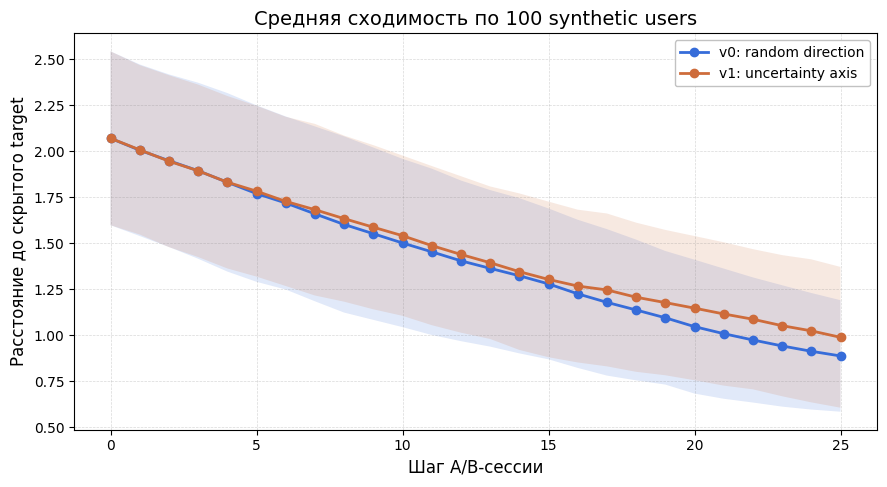

In [16]:
mean_random = curves_random.mean(axis=0)
mean_uncertainty = curves_uncertainty.mean(axis=0)

std_random = curves_random.std(axis=0)
std_uncertainty = curves_uncertainty.std(axis=0)

steps = np.arange(len(mean_random))

fig, ax = plt.subplots(figsize=(9, 5), facecolor="white")

ax.plot(
    steps,
    mean_random,
    marker="o",
    linewidth=2,
    label="v0: random direction",
)

ax.plot(
    steps,
    mean_uncertainty,
    marker="o",
    linewidth=2,
    label="v1: uncertainty axis",
)

ax.fill_between(
    steps,
    mean_random - std_random,
    mean_random + std_random,
    alpha=0.15,
)

ax.fill_between(
    steps,
    mean_uncertainty - std_uncertainty,
    mean_uncertainty + std_uncertainty,
    alpha=0.15,
)

ax.set_title("Средняя сходимость по 100 synthetic users")
ax.set_xlabel("Шаг A/B-сессии")
ax.set_ylabel("Расстояние до скрытого target")

ax.grid(True, alpha=0.3, linestyle="--", color="gray")
ax.legend(frameon=True, facecolor="white", edgecolor="0.75", framealpha=0.95)

plt.tight_layout()
plt.show()

## Вывод по batch-эксперименту v0_random vs v1_uncertainty_axis

В batch-эксперименте были сравнены две стратегии генерации A/B-кандидатов на 100 синтетических пользователях. Для каждого пользователя задавался скрытый target-вектор в compact weighted 8D-пространстве, после чего обе стратегии запускались на одинаковом числе шагов A/B-сессии.

Результаты показывают, что обе стратегии в среднем уменьшают расстояние до скрытого target, то есть базовый контур персонализации работает корректно. Однако стратегия `v1_uncertainty_axis` не улучшила baseline `v0_random`.

Среднее финальное расстояние для `v0_random` составило 0.888, а для `v1_uncertainty_axis` — 0.989. Среднее улучшение относительно начального расстояния составило 57.25% для `v0_random` и 52.59% для `v1_uncertainty_axis`. Кроме того, `v1_uncertainty_axis` выиграла у `v0_random` только в 38% сессий по `final_distance` и в 36% сессий по `best_distance`.

Это показывает, что простая стратегия выбора одной наиболее неопределённой оси не является достаточной для улучшения Pair Generator. Вероятная причина состоит в том, что target пользователя является многомерным: предпочтения одновременно зависят от нескольких признаков, тогда как `v1_uncertainty_axis` изменяет только один параметр за шаг. В отличие от этого, `v0_random` задаёт A/B-вопросы вдоль случайных направлений в 8D-пространстве и иногда сразу изменяет несколько признаков в полезной комбинации.

Таким образом, `v1_uncertainty_axis` полезна как интерпретируемый диагностический baseline, но не как финальная стратегия генерации пар. Следующим шагом является разработка `v2_hybrid` стратегии, которая будет совмещать преимущества случайных многомерных направлений и осевых uncertainty-вопросов.